<a href="https://colab.research.google.com/github/sidharth2733mba25fin-ops/COLLAB-FILES/blob/main/Fraud_Detection_Risk_Fairness_H2O_AutoML_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 2–4: Prediction, Risk and Fairness using No-Code AI

## Lab Title
Fraud Detection and Bias Detection using H2O AutoML

## Objective
In this lab, students will understand how AI is used in finance for:

1. Fraud detection
2. Risk prediction
3. Bias detection
4. Fairness understanding

This lab is designed for MBA Finance students. The aim is not to write complex code, but to understand how an AutoML system builds a model, makes predictions, and how finance teams check whether the model is fair.

---

## Business Context
Banks and financial institutions process thousands or millions of transactions every day. Some transactions may be fraudulent. AI can help detect suspicious transactions faster than manual checking.

However, AI models can also become unfair if the data contains bias. For example, if one customer group is incorrectly flagged more often than another, it can create fairness and compliance issues.

---

## What Students Will Learn
- How fraud prediction works
- How AutoML automatically builds models
- How to interpret model output
- How to check whether predictions differ across customer groups
- Why fairness matters in financial AI systems

---

## Key Concepts

| Concept | Meaning |
|---|---|
| Prediction | AI predicts whether a transaction is normal or fraud |
| Risk | Suspicious transaction pattern |
| Bias | When AI treats one group differently without valid reason |
| Fairness | Ensuring model outcomes are not unfair to a group |
| AutoML | Automatic Machine Learning; AI builds and selects models automatically |

---

## Lab Workflow
1. Install and start H2O AutoML
2. Create a synthetic fraud dataset inside the notebook
3. Train a fraud detection model
4. Make predictions
5. Evaluate model performance
6. Add a protected attribute for fairness analysis
7. Compare fraud prediction rates across groups
8. Visualize potential bias using charts

---

## Important Teaching Note
Fraud detection is not only about accuracy. In finance, we must also ask:

- Is the model catching fraud?
- Is the model wrongly flagging genuine customers?
- Is one customer group being flagged more than another?
- Can we justify the model decision during audit?

---

## Instruction
Run each cell one by one using Shift + Enter.

In [ ]:
# CELL 1: Install H2O AutoML
# H2O AutoML is used to automatically build machine learning models.
# Students do not need to manually choose algorithms like Random Forest or XGBoost.

!pip install -q -f http://h2o-release.s3.amazonaws.com/h2o/latest_stable_Py.html h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 4.8 MB/s eta 0:00:00


In [ ]:
# CELL 2: Import required libraries and start H2O
# pandas and numpy are used to create and handle the dataset.
# matplotlib is used for simple charts.
# H2O is the AutoML engine.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h2o

# Start H2O cluster
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp8ic7_wv3
  JVM stdout: /tmp/tmp8ic7_wv3/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp8ic7_wv3/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,07 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 21 days
H2O_cluster_name:,H2O_from_python_unknownUser_i7gpvo
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [ ]:
# CELL 3: Create a clean synthetic fraud dataset inside Colab
# This avoids downloading or uploading any external dataset.
# The dataset is imaginary but realistic enough for classroom learning.

np.random.seed(42)

# Number of transactions
n = 1000

# Create customer groups for fairness analysis
# Group_A and Group_B are hypothetical customer groups.
# In real financial AI, protected attributes may include gender, age group, region, etc.
customer_group = np.random.choice(["Group_A", "Group_B"], size=n, p=[0.55, 0.45])

# Create transaction features
transaction_amount = np.random.randint(100, 80000, n)
transaction_time = np.random.randint(0, 24, n)
account_age_months = np.random.randint(1, 120, n)
past_failed_transactions = np.random.poisson(1.2, n)
location_risk = np.random.choice(["Low", "Medium", "High"], size=n, p=[0.65, 0.25, 0.10])
device_type = np.random.choice(["Known_Device", "New_Device"], size=n, p=[0.75, 0.25])

# Create fraud probability using business-like logic
# Higher transaction amount, risky location, new device, and failed transactions increase fraud probability.
fraud_score = (
    0.000035 * transaction_amount
    + 0.35 * (transaction_time >= 22)
    + 0.45 * (past_failed_transactions >= 3)
    + 0.65 * (location_risk == "High")
    + 0.40 * (device_type == "New_Device")
)

# Add a small bias effect for teaching fairness
# This is intentionally added to demonstrate how bias can be detected.
# It does not mean any real group is risky.
fraud_score = fraud_score + 0.25 * (customer_group == "Group_B")

# Convert score to probability
fraud_probability = 1 / (1 + np.exp(-(fraud_score - 3.2)))

# Create fraud label from probability
fraud = np.random.binomial(1, fraud_probability)

# Build dataframe
data = pd.DataFrame({
    "Transaction_Amount": transaction_amount,
    "Transaction_Time": transaction_time,
    "Account_Age_Months": account_age_months,
    "Past_Failed_Transactions": past_failed_transactions,
    "Location_Risk": location_risk,
    "Device_Type": device_type,
    "Customer_Group": customer_group,
    "Fraud": fraud
})

# Display first 10 rows
data.head(10)

,Transaction_Amount,Transaction_Time,Account_Age_Months,Past_Failed_Transactions,Location_Risk,Device_Type,Customer_Group,Fraud
0,57234,7,114,0,Medium,Known_Device,Group_A,0
1,20591,1,81,2,Medium,Known_Device,Group_B,0
2,1441,21,51,0,Low,New_Device,Group_B,0
3,44723,12,53,0,Low,Known_Device,Group_B,1
4,438,20,78,2,Low,Known_Device,Group_A,0
5,71531,15,91,1,Low,Known_Device,Group_A,0
6,12354,1,82,1,High,Known_Device,Group_A,0
7,51960,10,92,1,Low,New_Device,Group_B,0
8,11444,9,51,1,Medium,Known_Device,Group_B,0
9,1850,14,47,1,High,Known_Device,Group_B,1


In [ ]:
# CELL 4: Understand the dataset
# This shows the number of rows, columns, and fraud distribution.
# In fraud detection, fraud cases are usually fewer than normal cases.

print("Dataset shape:", data.shape)
print("\nFraud value counts:")
print(data["Fraud"].value_counts())

print("\nFraud percentage:")
print((data["Fraud"].value_counts(normalize=True) * 100).round(2))

print("\nCustomer group distribution:")
print(data["Customer_Group"].value_counts())

Dataset shape: (1000, 8)

Fraud value counts:
Fraud
0    809
1    191
Name: count, dtype: int64

Fraud percentage:
Fraud
0    80.9
1    19.1
Name: proportion, dtype: float64

Customer group distribution:
Customer_Group
Group_A    559
Group_B    441
Name: count, dtype: int64


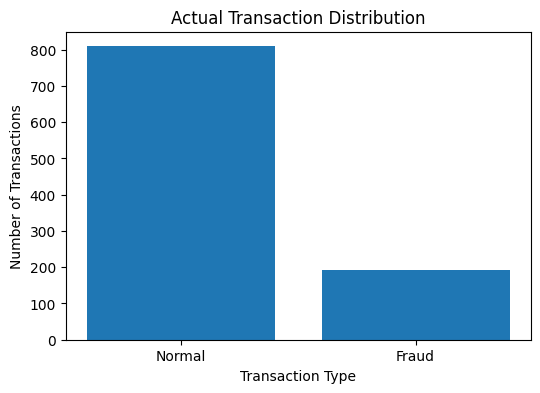

In [ ]:
# CELL 5: Visualize actual fraud distribution
# This chart shows how many transactions are normal vs fraud.

fraud_counts = data["Fraud"].map({0: "Normal", 1: "Fraud"}).value_counts()

plt.figure(figsize=(6, 4))
plt.bar(fraud_counts.index, fraud_counts.values)
plt.title("Actual Transaction Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

In [ ]:
# CELL 6: Convert pandas dataframe to H2O Frame
# H2O requires data in H2OFrame format.
# Fraud is converted into a categorical variable because this is a classification problem.

h2o_data = h2o.H2OFrame(data)
h2o_data["Fraud"] = h2o_data["Fraud"].asfactor()

# Display summary
h2o_data.describe()

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


Rows:1000
Cols:8

,Transaction_Amount,Transaction_Time,Account_Age_Months,Past_Failed_Transactions,Location_Risk,Device_Type,Customer_Group,Fraud
type,int,int,int,int,enum,enum,enum,enum
mins,263.0,0.0,1.0,0.0,,,,
mean,40453.48499999998,11.811999999999987,60.65000000000003,1.1649999999999991,,,,
maxs,79771.0,23.0,119.0,5.0,,,,
sigma,22683.52165234329,7.002691889101909,34.09721572386987,1.0802508699102915,,,,
zeros,0,36,0,308,,,,
missing,0,0,0,0,0,0,0,0
0,57234.0,7.0,114.0,0.0,Medium,Known_Device,Group_A,0
1,20591.0,1.0,81.0,2.0,Medium,Known_Device,Group_B,0
2,1441.0,21.0,51.0,0.0,Low,New_Device,Group_B,0


In [ ]:
# CELL 7: Split data into training and testing sets
# Training data is used to build the model.
# Testing data is used to check model performance on unseen transactions.

train, test = h2o_data.split_frame(ratios=[0.8], seed=42)

print("Training rows:", train.nrows)
print("Testing rows:", test.nrows)

Training rows: 788
Testing rows: 212


In [ ]:
# CELL 8: Train fraud detection model using H2O AutoML
# AutoML automatically trains multiple models and selects the best one.
# We are excluding Customer_Group from model training to avoid directly using group identity.
# Later, we still use Customer_Group to check fairness in predictions.

from h2o.automl import H2OAutoML

target = "Fraud"
features = [col for col in h2o_data.columns if col not in ["Fraud", "Customer_Group"]]

aml = H2OAutoML(
    max_models=8,
    seed=42,
    sort_metric="AUC",
    balance_classes=True
)

aml.train(x=features, y=target, training_frame=train)

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),3/8
# GBM base models (used / total),1/4
# XGBoost base models (used / total),1/2
# GLM base models (used / total),1/1
# DRF base models (used / total),0/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5
Metalearner fold_column,None


In [ ]:
# CELL 9: View AutoML leaderboard
# The leaderboard shows all models built by AutoML.
# The top model is considered the best according to the selected metric.

aml.leaderboard

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
StackedEnsemble_AllModels_1_AutoML_1_20260503_123742,0.678648,0.452092,0.322855,0.346622,0.377124,0.142222
GLM_1_AutoML_1_20260503_123742,0.677111,0.452615,0.321192,0.341639,0.377747,0.142693
StackedEnsemble_BestOfFamily_1_AutoML_1_20260503_123742,0.6677,0.456483,0.309876,0.347994,0.378845,0.143523
GBM_4_AutoML_1_20260503_123742,0.658831,0.482069,0.297507,0.359143,0.385805,0.148846
GBM_1_AutoML_1_20260503_123742,0.64545,0.461594,0.30616,0.349599,0.381123,0.145255
GBM_2_AutoML_1_20260503_123742,0.637321,0.481527,0.288762,0.367209,0.385629,0.148709
DRF_1_AutoML_1_20260503_123742,0.632812,0.714703,0.283856,0.373818,0.396742,0.157404
GBM_3_AutoML_1_20260503_123742,0.632696,0.487506,0.269239,0.380701,0.388717,0.151101
XGBoost_1_AutoML_1_20260503_123742,0.630184,0.61589,0.271225,0.38011,0.455688,0.207652
XGBoost_2_AutoML_1_20260503_123742,0.623485,0.601907,0.280198,0.388091,0.445271,0.198267


In [ ]:
# CELL 10: Evaluate model performance on test data
# AUC, precision, recall, and confusion matrix help us understand model quality.

performance = aml.leader.model_performance(test)
print(performance)

ModelMetricsBinomialGLM: stackedensemble
** Reported on test data. **

MSE: 0.14855580119851508
RMSE: 0.38542937251656767
LogLoss: 0.45949634909829123
AUC: 0.7246456584560341
AUCPR: 0.33762025080825586
Gini: 0.44929131691206825
Null degrees of freedom: 211
Residual degrees of freedom: 208
Null deviance: 214.1306909484706
Residual deviance: 194.82645201767545
AIC: 202.82645201767545

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.2248149578382309
       0    1    Error    Rate
-----  ---  ---  -------  ------------
0      129  40   0.2367   (40.0/169.0)
1      16   27   0.3721   (16.0/43.0)
Total  145  67   0.2642   (56.0/212.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.224815     0.490909  66
max f2                       0.111618     0.632716  151
max f0point5                 0.237135     0.441696  59
max accurac

## Simple Explanation of Metrics

| Metric | Simple Meaning | Finance Interpretation |
|---|---|---|
| Accuracy | How often the model is correct | Overall correctness |
| Precision | When AI says fraud, how often it is actually fraud | Avoids wrongly accusing genuine transactions |
| Recall | Out of all actual frauds, how many AI catches | Important because missing fraud is costly |
| AUC | How well model separates fraud and normal cases | Higher is better |

In fraud detection, **recall is very important** because missing fraud can create financial loss.

In [ ]:
# CELL 11: Make predictions on test data
# The model predicts whether each transaction is Normal (0) or Fraud (1).

predictions = aml.leader.predict(test)
predictions.head(10)

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


predict,p0,p1
0,0.754586,0.245414
0,0.873803,0.126197
0,0.922025,0.0779755
0,0.757939,0.242061
1,0.636587,0.363413
0,0.850474,0.149526
1,0.702174,0.297826
1,0.674344,0.325656
0,0.89607,0.10393
0,0.84887,0.15113


In [ ]:
# CELL 12: Combine test data with predictions for analysis
# We convert H2O frames back to pandas dataframes for easy charts and group analysis.

test_df = test.as_data_frame()
pred_df = predictions.as_data_frame()

# Add prediction columns
test_df["Predicted_Fraud"] = pred_df["predict"].astype(int)
test_df["Fraud_Probability"] = pred_df["p1"]

# Display sample output
test_df.head(10)

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,Transaction_Amount,Transaction_Time,Account_Age_Months,Past_Failed_Transactions,Location_Risk,Device_Type,Customer_Group,Fraud,Predicted_Fraud,Fraud_Probability
0,54856,16,111,0,Low,New_Device,Group_A,0,0,0.245414
1,15996,8,35,3,Low,Known_Device,Group_A,0,0,0.126197
2,12282,11,113,2,Medium,Known_Device,Group_A,0,0,0.077975
3,56376,18,97,1,Low,Known_Device,Group_A,1,0,0.242061
4,73643,16,69,1,Low,Known_Device,Group_A,1,1,0.363413
5,41886,11,13,2,Medium,New_Device,Group_A,0,0,0.149526
6,57232,11,67,0,High,New_Device,Group_B,0,1,0.297826
7,79045,10,54,0,Low,Known_Device,Group_A,1,1,0.325656
8,41098,12,80,0,Medium,Known_Device,Group_B,0,0,0.103930
9,44647,20,41,2,Low,Known_Device,Group_B,1,0,0.151130


In [ ]:
# CELL 13: Create confusion matrix manually
# This helps students understand correct and incorrect predictions.

confusion = pd.crosstab(
    test_df["Fraud"],
    test_df["Predicted_Fraud"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

print("Confusion Matrix")
print(confusion)

# Explanation labels:
# Actual 0, Predicted 0 = Correct normal transaction
# Actual 0, Predicted 1 = False alarm
# Actual 1, Predicted 0 = Missed fraud
# Actual 1, Predicted 1 = Correct fraud detection

Confusion Matrix
Predicted    0   1
Actual            
0          138  31
1           25  18


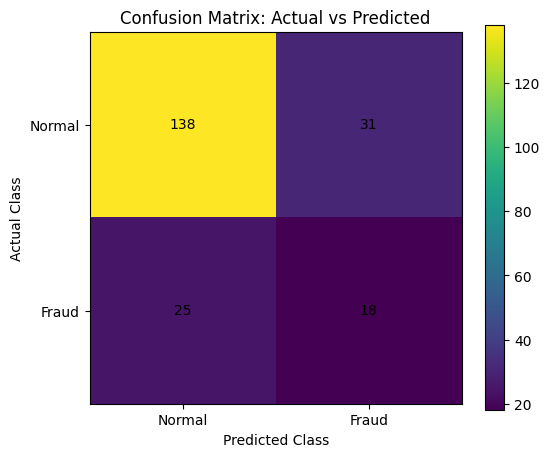

In [ ]:
# CELL 14: Visualize confusion matrix
# This chart makes model errors easier to explain in class.

plt.figure(figsize=(6, 5))
plt.imshow(confusion.values)
plt.title("Confusion Matrix: Actual vs Predicted")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yticks([0, 1], ["Normal", "Fraud"])

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        plt.text(j, i, confusion.values[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

# Bias and Fairness Detection

Now we move from prediction to fairness.

The question is not only: **Can AI detect fraud?**

The deeper question is: **Is AI treating different customer groups fairly?**

We will compare prediction results for two hypothetical groups: Group_A and Group_B.

In [ ]:
# CELL 15: Actual fraud rate by customer group
# This checks whether the original dataset itself has different fraud rates across groups.
# If the data is imbalanced or biased, the model may learn that pattern.

actual_fraud_by_group = test_df.groupby("Customer_Group")["Fraud"].mean() * 100

print("Actual fraud rate by customer group (%):")
print(actual_fraud_by_group.round(2))

Actual fraud rate by customer group (%):
Customer_Group
Group_A    16.81
Group_B    24.73
Name: Fraud, dtype: float64


In [ ]:
# CELL 16: Predicted fraud rate by customer group
# This checks whether the model is flagging one group more often than another.

predicted_fraud_by_group = test_df.groupby("Customer_Group")["Predicted_Fraud"].mean() * 100

print("Predicted fraud rate by customer group (%):")
print(predicted_fraud_by_group.round(2))

Predicted fraud rate by customer group (%):
Customer_Group
Group_A    15.13
Group_B    33.33
Name: Predicted_Fraud, dtype: float64


                Actual Fraud Rate (%)  Predicted Fraud Rate (%)
Customer_Group                                                 
Group_A                         16.81                     15.13
Group_B                         24.73                     33.33


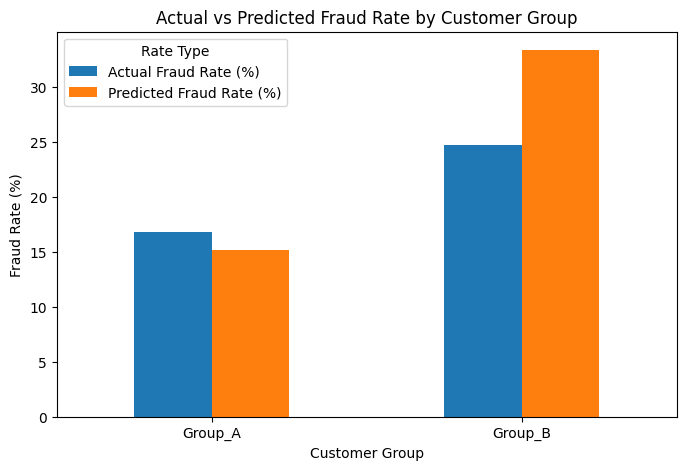

In [ ]:
# CELL 17: Visual chart for actual vs predicted fraud rate by group
# This chart helps students visually detect whether one group is flagged more often.

bias_table = pd.DataFrame({
    "Actual Fraud Rate (%)": actual_fraud_by_group,
    "Predicted Fraud Rate (%)": predicted_fraud_by_group
}).round(2)

print(bias_table)

bias_table.plot(kind="bar", figsize=(8, 5))
plt.title("Actual vs Predicted Fraud Rate by Customer Group")
plt.xlabel("Customer Group")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Rate Type")
plt.show()

In [ ]:
# CELL 18: False positive rate by group
# False Positive means the model predicted fraud, but the transaction was actually normal.
# In finance, false positives can frustrate genuine customers.

def false_positive_rate(group_df):
    actual_normal = group_df[group_df["Fraud"] == 0]
    if len(actual_normal) == 0:
        return np.nan
    return (actual_normal["Predicted_Fraud"].mean() * 100)

fpr_by_group = test_df.groupby("Customer_Group").apply(false_positive_rate)

print("False positive rate by customer group (%):")
print(fpr_by_group.round(2))

False positive rate by customer group (%):
Customer_Group
Group_A    11.11
Group_B    28.57
dtype: float64


/tmp/ipykernel_7970/1653065136.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fpr_by_group = test_df.groupby("Customer_Group").apply(false_positive_rate)


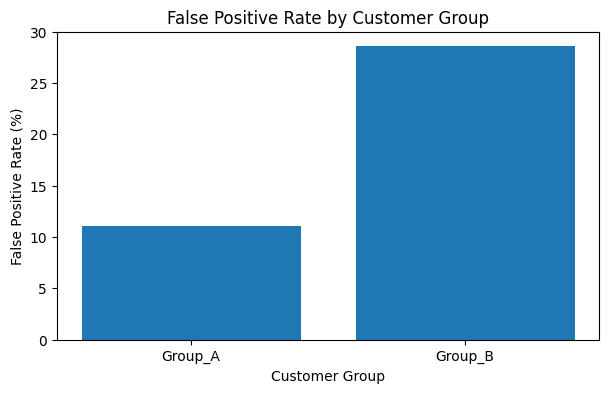

In [ ]:
# CELL 19: Visual chart for false positive rate by group
# If one group has much higher false positives, that group may face unfair inconvenience.

plt.figure(figsize=(7, 4))
plt.bar(fpr_by_group.index, fpr_by_group.values)
plt.title("False Positive Rate by Customer Group")
plt.xlabel("Customer Group")
plt.ylabel("False Positive Rate (%)")
plt.show()

Average predicted fraud probability by customer group (%):
Customer_Group
Group_A    16.57
Group_B    19.92
Name: Fraud_Probability, dtype: float64


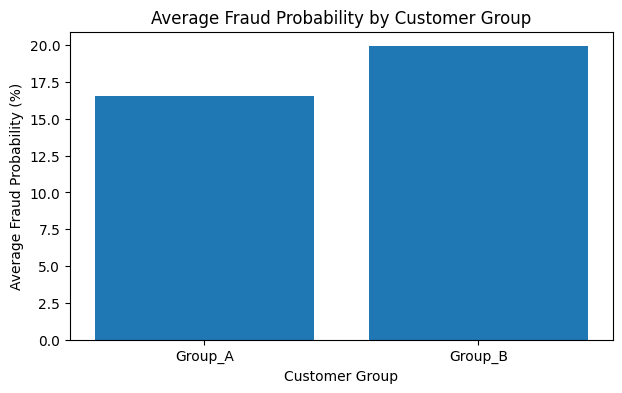

In [ ]:
# CELL 20: Average fraud probability by group
# This checks whether the model gives one group higher average fraud scores.

avg_probability_by_group = test_df.groupby("Customer_Group")["Fraud_Probability"].mean() * 100

print("Average predicted fraud probability by customer group (%):")
print(avg_probability_by_group.round(2))

plt.figure(figsize=(7, 4))
plt.bar(avg_probability_by_group.index, avg_probability_by_group.values)
plt.title("Average Fraud Probability by Customer Group")
plt.xlabel("Customer Group")
plt.ylabel("Average Fraud Probability (%)")
plt.show()

In [ ]:
# CELL 21: Create a simple fairness summary table
# This table combines the most important fairness indicators.

fairness_summary = pd.DataFrame({
    "Actual Fraud Rate (%)": actual_fraud_by_group,
    "Predicted Fraud Rate (%)": predicted_fraud_by_group,
    "False Positive Rate (%)": fpr_by_group,
    "Average Fraud Probability (%)": avg_probability_by_group
}).round(2)

fairness_summary

,Actual Fraud Rate (%),Predicted Fraud Rate (%),False Positive Rate (%),Average Fraud Probability (%)
Customer_Group,,,,
Group_A,16.81,15.13,11.11,16.57
Group_B,24.73,33.33,28.57,19.92


# Classroom Interpretation Guide

Use these points while explaining the fairness results:

## 1. Actual Fraud Rate
This shows how much fraud actually exists in each group.

## 2. Predicted Fraud Rate
This shows how often the model flags each group as fraud.

## 3. False Positive Rate
This is very important in finance. It tells us how often genuine customers are wrongly flagged as fraud.

## 4. Average Fraud Probability
This shows whether the model generally assigns higher risk scores to one group.

---

## Important Teaching Line
A model can be accurate overall but still unfair to a particular group.

---

## Discussion Questions
1. Which group is flagged more often by the model?
2. Is that difference justified by actual fraud rate?
3. Which group has a higher false positive rate?
4. What business risk can arise from false positives?
5. What compliance or ethical risk can arise from biased predictions?

---

## Final Learning Outcome
Students should understand that financial AI systems need three checks:

1. Prediction performance
2. Risk usefulness
3. Fairness and bias control

In [ ]:
# CELL 22: Shut down H2O when lab is complete
# This frees system resources.

h2o.cluster().shutdown(prompt=False)

H2O session _sid_9b50 closed.
